<a href="https://colab.research.google.com/github/AIPI510/aipi510-fall24/blob/lecture-code/week_5_lecture_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis - COVID 19 Dataset

There are 8 datasets with actual personal data of interest. Let's evaluate them individually first, then combine them and perform more analyis later. 

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load each dataset from the data folder
df_bp = pd.read_csv("../data/week4/blood_pressure.csv")
df_hr = pd.read_csv("../data/week4/heart_rate.csv")
df_hrv = pd.read_csv("../data/week4/hrv_measurements.csv")
df_ptps = pd.read_csv("../data/week4/participants.csv")
df_sleep = pd.read_csv("../data/week4/sleep.csv")
df_surveys = pd.read_csv("../data/week4/surveys.csv")
df_wrbls = pd.read_csv("../data/week4/wearables.csv")
df_wthr = pd.read_csv("../data/week4/weather.csv")

## Questions we are asking:
* What are the dimensions of the dataset (number of rows and columns)?
* What are the data types of the variables (numerical, categorical, text, etc.)?
* Are there any missing values, and if so, how are they represented?


In [4]:
# Data Structure
print("Data Structure - Blood Pressure")
print("---------------")
print(f"Dimensions: {df_bp.shape}")
print(f"Data Types:\n{df_bp.dtypes}")
print(f"Missing Values:\n{df_bp.isnull().sum()}")
print("xxxxxxxxxxxxxx\n")

print("Data Structure - Heart Rate")
print("---------------")
print(f"Dimensions: {df_hr.shape}")
print(f"Data Types:\n{df_hr.dtypes}")
print(f"Missing Values:\n{df_hr.isnull().sum()}")
print("xxxxxxxxxxxxxx\n")

print("Data Structure - HRV")
print("---------------")
print(f"Dimensions: {df_hrv.shape}")
print(f"Data Types:\n{df_hrv.dtypes}")
print(f"Missing Values:\n{df_hrv.isnull().sum()}")
print("xxxxxxxxxxxxxx\n")

print("Data Structure - Participants")
print("---------------")
print(f"Dimensions: {df_ptps.shape}")
print(f"Data Types:\n{df_ptps.dtypes}")
print(f"Missing Values:\n{df_ptps.isnull().sum()}")
print("xxxxxxxxxxxxxx\n")

print("Data Structure - Surveys")
print("---------------")
print(f"Dimensions: {df_surveys.shape}")
print(f"Data Types:\n{df_surveys.dtypes}")
print(f"Missing Values:\n{df_surveys.isnull().sum()}")
print("xxxxxxxxxxxxxx\n")

print("Data Structure - Wearables")
print("---------------")
print(f"Dimensions: {df_wrbls.shape}")
print(f"Data Types:\n{df_wrbls.dtypes}")
print(f"Missing Values:\n{df_wrbls.isnull().sum()}")
print("xxxxxxxxxxxxxx\n")

print("Data Structure - Weather")
print("---------------")
print(f"Dimensions: {df_wthr.shape}")
print(f"Data Types:\n{df_wthr.dtypes}")
print(f"Missing Values:\n{df_wthr.isnull().sum()}")
print("xxxxxxxxxxxxxx\n")


Data Structure - Blood Pressure
---------------
Dimensions: (721, 8)
Data Types:
user_code                    object
measurement_datetime         object
diastolic                     int64
systolic                      int64
functional_changes_index    float64
circulatory_efficiency      float64
kerdo_vegetation_index      float64
robinson_index              float64
dtype: object
Missing Values:
user_code                     0
measurement_datetime          0
diastolic                     0
systolic                      0
functional_changes_index    422
circulatory_efficiency      422
kerdo_vegetation_index      438
robinson_index              422
dtype: int64
xxxxxxxxxxxxxx

Data Structure - Heart Rate
---------------
Dimensions: (523783, 4)
Data Types:
user_code     object
datetime      object
heart_rate     int64
is_resting     int64
dtype: object
Missing Values:
user_code     0
datetime      0
heart_rate    0
is_resting    0
dtype: int64
xxxxxxxxxxxxxx

Data Structure - HRV
--------

## Interpretation

Across all 8 datasets, we have a ton of features and dimensions. Not all datasets have the same number of observations, so we cannot consider combining them yet. We must align user_code. Luckily, they all have user_codes, so that will come into play later. 

Before we can perform more EDA, I want to combine all of these datasets into one. To begin, let's eliminate features from each dataset where there is at least 5% missing entries. The reason for this is a lot of features have much more than 5% missing, and this reduces the amount of missing values work we will need to do across so many features. 

In [5]:
# I probably should have done this earlier, but make a dict of 
# the dataframes:

dataframes = {
    "Blood Pressure": df_bp,
    "Heart Rate": df_hr,
    "HRV": df_hrv,
    "Participants": df_ptps,
    "Sleep": df_sleep,
    "Surveys": df_surveys,
    "Wearables": df_wrbls,
    "Weather": df_wthr
}

# Now, for each dataframe/dataset, drop any with >= 5% missing values

for name, df in dataframes.items():
    missing_pct = df.isnull().mean()
    columns_to_drop = missing_pct[missing_pct >= 0.05].index

    print(f"{name}: dropping {list(columns_to_drop)}")

    df.drop(columns=columns_to_drop, inplace=True)

Blood Pressure: dropping ['functional_changes_index', 'circulatory_efficiency', 'kerdo_vegetation_index', 'robinson_index']
Heart Rate: dropping []
HRV: dropping ['how_sleep', 'tags']
Participants: dropping ['city', 'symptoms_onset']
Sleep: dropping ['sleep_awake_duration', 'sleep_rem_duration', 'sleep_light_duration', 'sleep_deep_duration', 'pulse_min', 'pulse_max', 'pulse_average']
Surveys: dropping []
Wearables: dropping ['resting_pulse', 'pulse_average', 'pulse_min', 'pulse_max', 'average_spo2_value', 'body_temperature_avg', 'stand_hours_total', 'steps_count', 'distance', 'steps_speed', 'total_number_of_flights_climbed', 'active_calories_burned', 'average_headphone_exposure', 'average_environment_exposure']
Weather: dropping []


In [6]:
# Now, reinspect the data
for name, df in dataframes.items():
    print("=" * 60)
    print(f"{name.upper()}")
    print("=" * 60)

    print(f"\nShape: {df.shape}")

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nFirst 5 Rows:")
    display(df.head())

    print("\n")

BLOOD PRESSURE

Shape: (721, 4)

Data Types:
user_code               object
measurement_datetime    object
diastolic                int64
systolic                 int64
dtype: object

Missing Values:
user_code               0
measurement_datetime    0
diastolic               0
systolic                0
dtype: int64

First 5 Rows:


,user_code,measurement_datetime,diastolic,systolic
0,01bad5a519,2020-04-29 22:33:33,100,150
1,01bad5a519,2020-04-30 01:33:33,100,150
2,01bad5a519,2020-04-30 09:16:38,95,140
3,01bad5a519,2020-04-30 12:16:38,95,140
4,01bad5a519,2020-05-01 06:58:06,80,130




HEART RATE

Shape: (523783, 4)

Data Types:
user_code     object
datetime      object
heart_rate     int64
is_resting     int64
dtype: object

Missing Values:
user_code     0
datetime      0
heart_rate    0
is_resting    0
dtype: int64

First 5 Rows:


,user_code,datetime,heart_rate,is_resting
0,007b8190cf,2020-04-26 04:49:25,70,0
1,01bad5a519,2020-04-23 06:21:03,74,0
2,01bad5a519,2020-04-23 09:46:01,82,0
3,01bad5a519,2020-04-23 14:05:06,90,0
4,01bad5a519,2020-04-24 03:41:18,72,0




HRV

Shape: (3245, 20)

Data Types:
user_code                object
rr_code                  object
measurement_datetime     object
time_of_day              object
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf                      float64
hf                      float64
vlf                     float64
lfhf                    float64
total_power             float64
how_feel                  int64
how_mood                  int64
rr_data                  object
dtype: object

Missing Values:
user_code               0
rr_code                 0
measurement_datetime    0
time_of_day             0
bpm                     0
meanrr                  0
mxdmn                   0
sdnn                    0
rmssd                   0
pnn50                   0
mode                    0
amo  

...

,user_code,scale,created_at,value,text
0,01bad5a519,S_CORONA,2020-04-23,2,Symptoms are characteristic of coronavirus
1,01bad5a519,S_COVID_BLUISH,2020-04-23,1,User isn’t experiencing symptom
2,01bad5a519,S_COVID_BLUISH,2020-04-25,1,User isn’t experiencing symptom
3,01bad5a519,S_COVID_BLUISH,2020-04-27,1,User isn’t experiencing symptom
4,01bad5a519,S_COVID_BLUISH,2020-04-29,1,User isn’t experiencing symptom




WEARABLES

Shape: (3098, 4)

Data Types:
user_code                 object
day                       object
basal_calories_burned    float64
total_calories_burned    float64
dtype: object

Missing Values:
user_code                0
day                      0
basal_calories_burned    1
total_calories_burned    1
dtype: int64

First 5 Rows:


,user_code,day,basal_calories_burned,total_calories_burned
0,007b8190cf,2020-04-26,2859.0,2859.0
1,01bad5a519,2020-02-12,2624.0,2624.0
2,01bad5a519,2020-02-13,2624.0,2624.0
3,01bad5a519,2020-02-15,2624.0,2624.0
4,01bad5a519,2020-02-16,2624.0,2624.0




WEATHER

Shape: (1717, 7)

Data Types:
user_code                object
day                      object
avg_temperature_C       float64
atmospheric_pressure    float64
precip_intensity        float64
humidity                float64
clouds                  float64
dtype: object

Missing Values:
user_code               0
day                     0
avg_temperature_C       0
atmospheric_pressure    0
precip_intensity        0
humidity                0
clouds                  0
dtype: int64

First 5 Rows:


,user_code,day,avg_temperature_C,atmospheric_pressure,precip_intensity,humidity,clouds
0,013f6d3e5b,2020-05-22,18.0667,1017.6,0.0002,70.0,67.0
1,01bad5a519,2020-01-11,-1.2111,1016.4,0.0002,92.0,6.0
2,01bad5a519,2020-01-30,0.5056,1004.7,0.0009,85.0,100.0
3,01bad5a519,2020-04-02,-0.2444,994.4,0.0025,91.0,87.0
4,01bad5a519,2020-04-12,5.1778,1016.1,0.0000,61.0,91.0


## Interpretation

Now, we have features that are at least 95% populated across all observations. Let's now see how many users appear across all 8 datasets, seeing if we can feasibly make a master dataset

In [7]:
# Find user_codes that are present in EVERY dataset
common_users = set.intersection(
    *[set(df["user_code"].dropna().unique()) for df in dataframes.values()]
)

print(f"Number of users present in all datasets: {len(common_users)}")

# Filter every dataframe to only those common users
synced_dataframes = {}

for name, df in dataframes.items():
    synced_dataframes[name] = df[df["user_code"].isin(common_users)].copy()

    print(
        f"{name}: "
        f"{df['user_code'].nunique()} users -> "
        f"{synced_dataframes[name]['user_code'].nunique()} users, "
        f"{synced_dataframes[name].shape[0]} rows"
    )

# Inspect how many rows each user has in each dataset
print("\nRows per user in each synchronized dataset:")
print("-" * 50)

for name, df in synced_dataframes.items():
    counts = df.groupby("user_code").size()

    print(
        f"{name}: "
        f"min={counts.min()}, "
        f"median={counts.median()}, "
        f"max={counts.max()}"
    )

Number of users present in all datasets: 4
Blood Pressure: 28 users -> 4 users, 446 rows
Heart Rate: 79 users -> 4 users, 108112 rows
HRV: 185 users -> 4 users, 387 rows
Participants: 185 users -> 4 users, 4 rows
Sleep: 10 users -> 4 users, 179 rows
Surveys: 111 users -> 4 users, 184 rows
Wearables: 79 users -> 4 users, 517 rows
Weather: 104 users -> 4 users, 209 rows

Rows per user in each synchronized dataset:
--------------------------------------------------
Blood Pressure: min=2, median=55.5, max=333
Heart Rate: min=31, median=5369.5, max=97342
HRV: min=34, median=85.0, max=183
Participants: min=1, median=1.0, max=1
Sleep: min=1, median=35.0, max=108
Surveys: min=10, median=23.5, max=127
Wearables: min=108, median=123.5, max=162
Weather: min=32, median=49.0, max=79


## Interpretation

This gives us only 4 users, and thus four total rows using this rule to build our master spreadsheet. Seems like our rule is too strict, and we are trying to use too many datasets which unfortunately did not sample/synchronize the same users. Now, let's look at user coverage of each dataset to determine which onese should drive our master dataset. 

In [8]:
# Create a user-by-dataset coverage table

all_users = set()

for df in dataframes.values():
    all_users.update(df["user_code"].dropna().unique())

coverage = pd.DataFrame(index=sorted(all_users))

for name, df in dataframes.items():
    users_in_df = set(df["user_code"].dropna().unique())
    coverage[name] = coverage.index.isin(users_in_df)

# Number of datasets each user appears in
coverage["datasets_present"] = coverage.sum(axis=1)

# Sort users with the most complete data first
coverage = coverage.sort_values("datasets_present", ascending=False)

display(coverage)

print("\nNumber of users by dataset coverage:")
display(
    coverage["datasets_present"]
    .value_counts()
    .sort_index(ascending=False)
)

,Blood Pressure,Heart Rate,HRV,Participants,Sleep,Surveys,Wearables,Weather,datasets_present
9871ee5e7b,True,True,True,True,True,True,True,True,8
a1c2e6b2eb,True,True,True,True,True,True,True,True,8
276ab22485,True,True,True,True,True,True,True,True,8
6be5033971,True,True,True,True,True,True,True,True,8
295ed96279,True,True,True,True,False,True,True,True,7
...,...,...,...,...,...,...,...,...,...
b592b38671,False,False,True,True,False,False,False,False,2
33057503fc,False,False,True,True,False,False,False,False,2
3157b60ce8,False,False,True,True,False,False,False,False,2
c6c213b973,False,False,True,True,False,False,False,False,2



Number of users by dataset coverage:


datasets_present
8     4
7    19
6    45
5     6
4    24
3    46
2    41
Name: count, dtype: int64

In [9]:
print("Unique users per dataset:\n")

for name, df in dataframes.items():
    print(f"{name}: {df['user_code'].nunique()}")

Unique users per dataset:

Blood Pressure: 28
Heart Rate: 79
HRV: 185
Participants: 185
Sleep: 10
Surveys: 111
Wearables: 79
Weather: 104


In [10]:
dataset_names = list(dataframes.keys())

overlap = pd.DataFrame(
    index=dataset_names,
    columns=dataset_names,
    dtype=int
)

for name1 in dataset_names:
    users1 = set(dataframes[name1]["user_code"].dropna().unique())

    for name2 in dataset_names:
        users2 = set(dataframes[name2]["user_code"].dropna().unique())

        overlap.loc[name1, name2] = len(users1 & users2)

display(overlap)

,Blood Pressure,Heart Rate,HRV,Participants,Sleep,Surveys,Wearables,Weather
Blood Pressure,28.0,28.0,28.0,28.0,5.0,23.0,28.0,24.0
Heart Rate,28.0,79.0,79.0,79.0,10.0,66.0,79.0,65.0
HRV,28.0,79.0,185.0,185.0,10.0,111.0,79.0,104.0
Participants,28.0,79.0,185.0,185.0,10.0,111.0,79.0,104.0
Sleep,5.0,10.0,10.0,10.0,10.0,8.0,10.0,9.0
Surveys,23.0,66.0,111.0,111.0,8.0,111.0,66.0,76.0
Wearables,28.0,79.0,79.0,79.0,10.0,66.0,79.0,65.0
Weather,24.0,65.0,104.0,104.0,9.0,76.0,65.0,104.0


## Interpretation

There is a lot to unpack here. First, we see how trying to include all 8 datasets only gives us 4 users. Then we look at how many unique users there are per dataset. Finally, and most importantly, we check the overlap of each pair of datasets to see the user overlap. For example, we see 28 unique users present in blood pressure, and 28 unique in heart rate, which means we could get 28 unique samples from these two datasets if we combined them. If we only used particants and HRV, we could get the most total samples at 185. Since we really need a lot of samples in machine learning, I am leaning towards using the participants dataset with HRV since we get all 185 unique people there. Let's add in weather since it gives us 104 of those 185 which is good enough. Lets also add in Surveys since they give us 111 of 185 of those observations which is good enough. So we will now be dropping blood pressure, heart rate, sleep, and wearables unfortunately. I say unfortunately because these are good datasets to have, but they don't sample enough of our population of interest, so they would contribute too many missing values to our dataset. 

It is now time to combine unique user rows across the four kept datasets to make our master dataset of interest. We will perform EDA on it afterwards. 

In [11]:
# ============================================================
# Build master dataset: ONE ROW PER USER
# Core population = Participants + HRV (185 users)
# Optional datasets = Weather + Surveys
# ============================================================

# ---------- 1. Aggregate HRV to one row per user ----------
# Take the mean of each numeric HRV feature for each person
hrv_numeric = df_hrv.select_dtypes(include="number").columns

hrv_user = (
    df_hrv
    .groupby("user_code")[hrv_numeric]
    .mean()
    .add_prefix("hrv_")
    .reset_index()
)

# Also keep number of HRV measurements available for each user
hrv_counts = (
    df_hrv.groupby("user_code")
    .size()
    .reset_index(name="hrv_measurement_count")
)

hrv_user = hrv_user.merge(hrv_counts, on="user_code", how="left")


# ---------- 2. Aggregate weather to one row per user ----------
weather_numeric = df_wthr.select_dtypes(include="number").columns

weather_user = (
    df_wthr
    .groupby("user_code")[weather_numeric]
    .mean()
    .add_prefix("weather_")
    .reset_index()
)

weather_counts = (
    df_wthr.groupby("user_code")
    .size()
    .reset_index(name="weather_observation_count")
)

weather_user = weather_user.merge(
    weather_counts,
    on="user_code",
    how="left"
)


# ---------- 3. Aggregate surveys to one row per user ----------
# Different survey scales measure different things, so keep them
# as separate features rather than averaging all surveys together.
survey_user = (
    df_surveys
    .pivot_table(
        index="user_code",
        columns="scale",
        values="value",
        aggfunc="mean"
    )
    .add_prefix("survey_")
    .reset_index()
)

# Number of total survey responses from each person
survey_counts = (
    df_surveys.groupby("user_code")
    .size()
    .reset_index(name="survey_response_count")
)

survey_user = survey_user.merge(
    survey_counts,
    on="user_code",
    how="left"
)


# ---------- 4. Create the master dataset ----------

# Participants + HRV are our required/core datasets
master_df = df_ptps.merge(
    hrv_user,
    on="user_code",
    how="inner"
)

# Weather and Surveys are optional, so LEFT joins preserve
# all users from our core population
master_df = master_df.merge(
    weather_user,
    on="user_code",
    how="left"
)

master_df = master_df.merge(
    survey_user,
    on="user_code",
    how="left"
)


# ---------- 5. Inspect the finished master dataset ----------

print("MASTER DATASET")
print("=" * 60)

print(f"Shape: {master_df.shape}")
print(f"Unique users: {master_df['user_code'].nunique()}")

print("\nMissing values per feature:")
print(master_df.isnull().sum().sort_values(ascending=False))

print("\nFirst 5 rows:")
display(master_df.head())

MASTER DATASET
Shape: (185, 87)
Unique users: 185

Missing values per feature:
survey_S_DIAB_REASON4    184
survey_S_HRA_HORM        184
survey_S_HRA_DBT         184
survey_S_HEART_5         184
survey_S_HEART_4         184
                        ... 
hrv_lfhf                   0
hrv_total_power            0
hrv_how_feel               0
hrv_how_mood               0
user_code                  0
Length: 87, dtype: int64

First 5 rows:


,user_code,gender,age_range,country,height,weight,hrv_bpm,hrv_meanrr,hrv_mxdmn,hrv_sdnn,...,survey_S_HRA_OCD,survey_S_HRA_OVARY,survey_S_HRA_PANIC,survey_S_HRA_PERPAIN,survey_S_HRA_POST,survey_S_HRA_SLEEP,survey_S_HRA_SUGAR,survey_S_HRA_VARI,survey_S_HRA_VIT,survey_response_count
0,007b8190cf,m,25-34,Myanmar,170.18,96.162,72.500000,826.950000,0.115000,39.345500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,013f6d3e5b,f,18-24,Brazil,174.00,77.300,79.000000,763.370000,0.185000,63.517000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01bad5a519,m,45-54,Russia,178.00,92.000,77.744444,778.397111,0.093667,29.076133,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0
3,0210b20eea,f,25-34,Russia,169.00,60.000,78.400000,774.066000,0.132000,37.384600,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,024719e7da,f,45-54,Russia,158.00,68.500,72.000000,834.706667,0.200000,66.716667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Interpretation: 

We now have 185 synchronized observations by user_code, and 87 features across the 4 datasets. This is still too much! Still before EDA, lets drop some obvious features. 

In [12]:
# ============================================================
# First-pass feature cleanup
# Drop obviously unhelpful features before deeper EDA
# ============================================================

# 1. Drop identifier / bookkeeping columns
columns_to_drop = [
    "user_code",                  # identifier, not a predictive feature
    "hrv_measurement_count",      # number of measurements collected
    "weather_observation_count",  # number of weather observations collected
    "survey_response_count"       # number of survey responses collected
]

# Only drop them if they actually exist
columns_to_drop = [
    col for col in columns_to_drop
    if col in master_df.columns
]

master_df = master_df.drop(columns=columns_to_drop)


# 2. Drop features that are extremely sparse in the MASTER dataset
# Here: drop anything with 50% or more missing values
missing_pct = master_df.isnull().mean()

sparse_columns = missing_pct[
    missing_pct >= 0.50
].index.tolist()

print("Dropping extremely sparse features:")
for col in sparse_columns:
    print(f"{col}: {missing_pct[col] * 100:.1f}% missing")

master_df = master_df.drop(columns=sparse_columns)


# 3. Drop constant features
# A feature with only one unique value cannot explain anything
constant_columns = [
    col for col in master_df.columns
    if master_df[col].nunique(dropna=True) <= 1
]

print("\nDropping constant features:")
print(constant_columns)

master_df = master_df.drop(columns=constant_columns)


# 4. Inspect result
print("\nCLEANED MASTER DATASET")
print("=" * 60)
print(f"Shape: {master_df.shape}")

print("\nRemaining columns:")
print(master_df.columns.tolist())

print("\nMissing values:")
print(
    (master_df.isnull().mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

display(master_df.head())

Dropping extremely sparse features:
survey_S_CORONA: 63.2% missing
survey_S_COVID_BLUISH: 63.2% missing
survey_S_COVID_BREATH: 63.2% missing
survey_S_COVID_CONFUSION: 63.2% missing
survey_S_COVID_COUGH: 63.2% missing
survey_S_COVID_FATIGUE: 63.2% missing
survey_S_COVID_FEVER: 63.2% missing
survey_S_COVID_OVERALL: 63.2% missing
survey_S_COVID_PAIN: 63.2% missing
survey_S_COVID_SYMPTOMS: 97.8% missing
survey_S_COVID_TROUBLE: 63.2% missing
survey_S_DIABETES: 98.4% missing
survey_S_DIAB_REASON1: 99.5% missing
survey_S_DIAB_REASON2: 99.5% missing
survey_S_DIAB_REASON3: 98.4% missing
survey_S_DIAB_REASON4: 99.5% missing
survey_S_DIAB_REASON5: 98.9% missing
survey_S_DIAB_REASON6: 99.5% missing
survey_S_HEART: 91.9% missing
survey_S_HEART_1: 98.4% missing
survey_S_HEART_3: 98.4% missing
survey_S_HEART_4: 99.5% missing
survey_S_HEART_5: 99.5% missing
survey_S_HRA_ALC: 75.7% missing
survey_S_HRA_ALLERG: 94.1% missing
survey_S_HRA_ANEMIA: 97.8% missing
survey_S_HRA_ANX: 90.3% missing
survey_S_HRA

,gender,age_range,country,height,weight,hrv_bpm,hrv_meanrr,hrv_mxdmn,hrv_sdnn,hrv_rmssd,...,hrv_vlf,hrv_lfhf,hrv_total_power,hrv_how_feel,hrv_how_mood,weather_avg_temperature_C,weather_atmospheric_pressure,weather_precip_intensity,weather_humidity,weather_clouds
0,m,25-34,Myanmar,170.18,96.162,72.500000,826.950000,0.115000,39.345500,43.598000,...,221.500000,0.895500,1373.000000,0.0,-0.500000,NaN,NaN,NaN,NaN,NaN
1,f,18-24,Brazil,174.00,77.300,79.000000,763.370000,0.185000,63.517000,68.013000,...,956.500000,0.518500,2763.500000,-0.5,-1.000000,18.066700,1017.600000,0.000200,70.00,67.000000
2,m,45-54,Russia,178.00,92.000,77.744444,778.397111,0.093667,29.076133,25.537978,...,218.533333,1.934422,556.777778,0.0,0.011111,8.318166,1011.070834,0.002714,66.61,55.820002
3,f,25-34,Russia,169.00,60.000,78.400000,774.066000,0.132000,37.384600,29.732800,...,350.000000,5.308200,1220.400000,-0.8,0.400000,15.084750,1013.250000,0.015600,79.00,71.750000
4,f,45-54,Russia,158.00,68.500,72.000000,834.706667,0.200000,66.716667,74.369333,...,649.000000,0.689333,4334.666667,0.0,0.000000,8.894450,1012.950000,0.002450,72.00,50.000000


## Interpretation

We have now reduced the feature size from 87 to 25 features. This was done by dropping extremely sparse features specifically by imposing a much looser threshold of 50% instead of 5% like we did before. It is now time to perform some EDA on this dataset to get a better understanding of it. 

So far, we already know we have 185 observations with 25 features each. Double check below for sanity. 

In [13]:
# Quick summary of the cleaned master dataset

print("Dataset Dimensions:")
print(master_df.shape)

print("\nFeatures:")
print(master_df.columns.tolist())

print("\nMissing Values Per Feature:")
missing_summary = pd.DataFrame({
    "Missing Count": master_df.isnull().sum(),
    "Missing Percent": (master_df.isnull().mean() * 100).round(2)
})

display(missing_summary)

Dataset Dimensions:
(185, 25)

Features:
['gender', 'age_range', 'country', 'height', 'weight', 'hrv_bpm', 'hrv_meanrr', 'hrv_mxdmn', 'hrv_sdnn', 'hrv_rmssd', 'hrv_pnn50', 'hrv_mode', 'hrv_amo', 'hrv_lf', 'hrv_hf', 'hrv_vlf', 'hrv_lfhf', 'hrv_total_power', 'hrv_how_feel', 'hrv_how_mood', 'weather_avg_temperature_C', 'weather_atmospheric_pressure', 'weather_precip_intensity', 'weather_humidity', 'weather_clouds']

Missing Values Per Feature:


,Missing Count,Missing Percent
gender,0,0.00
age_range,0,0.00
country,6,3.24
height,2,1.08
weight,0,0.00
hrv_bpm,0,0.00
hrv_meanrr,0,0.00
hrv_mxdmn,0,0.00
hrv_sdnn,0,0.00
hrv_rmssd,0,0.00


## Interpretation

We now have a good understanding of our data. We see it mostly cares about the person's information, their hrv statistics, and the part of the world with its climate. All plausible features related to COVID-19. As mentioned, it'd be nice to have more/different ones, but because this dataset is so messy this is the reality of the situation. 

## EDA of Master Dataset

We begin with descriptive statistics:

* What are the central tendency measures (mean, median, mode) for numerical variables?
* What are the measures of dispersion (range, variance, standard deviation) for numerical variables?
* What is the distribution of the variables (normal, skewed, etc.)?

In [15]:
# Descriptive Statistics

numeric_columns = master_df.select_dtypes(include=[np.number]).columns

# Create one summary table with one row per feature
descriptive_stats = pd.DataFrame({
    "Mean": master_df[numeric_columns].mean(),
    "Median": master_df[numeric_columns].median(),
    "Std Dev": master_df[numeric_columns].std(),
    "Min": master_df[numeric_columns].min(),
    "Max": master_df[numeric_columns].max(),
    "Skewness": master_df[numeric_columns].skew(),
    "Kurtosis": master_df[numeric_columns].kurt()
})

# Round values to make output easier to read
descriptive_stats = descriptive_stats.round(3)

print("Descriptive Statistics")
print("----------------------")

display(descriptive_stats)

Descriptive Statistics
----------------------


,Mean,Median,Std Dev,Min,Max,Skewness,Kurtosis
height,169.976,168.000,12.400,132.080,250.000,2.910,17.553
weight,77.928,74.344,19.553,43.500,154.221,0.865,0.891
hrv_bpm,75.261,74.200,10.521,52.800,105.000,0.337,-0.034
hrv_meanrr,816.281,807.417,114.881,569.350,1143.012,0.352,-0.093
hrv_mxdmn,0.174,0.170,0.078,0.040,0.540,1.019,2.212
hrv_sdnn,51.090,50.855,20.994,12.442,154.597,0.965,2.822
hrv_rmssd,52.604,48.658,26.516,11.074,212.828,1.823,7.311
hrv_pnn50,19.083,16.279,13.838,0.000,80.862,1.244,2.533
hrv_mode,0.816,0.812,0.120,0.575,1.155,0.386,-0.063
hrv_amo,48.954,46.700,14.162,16.267,96.000,0.829,1.104


## Interpretation

We see mean and median to get a sense of some averages. Standard deviation shows how much values vary from these averages. In general, we are observing a lot of skewness in the data so it is not very normally distributed. Kurtosis shows us if heavy values lie in the tails for certain variables.  

## Correlation and Patterns in the data:

Questions we are asking:

* Is there any correlation between pairs of numerical variables?
* Are there any noticeable patterns or trends in the data?
* How are categorical variables related to numerical variables?



Variable Relationships
----------------------


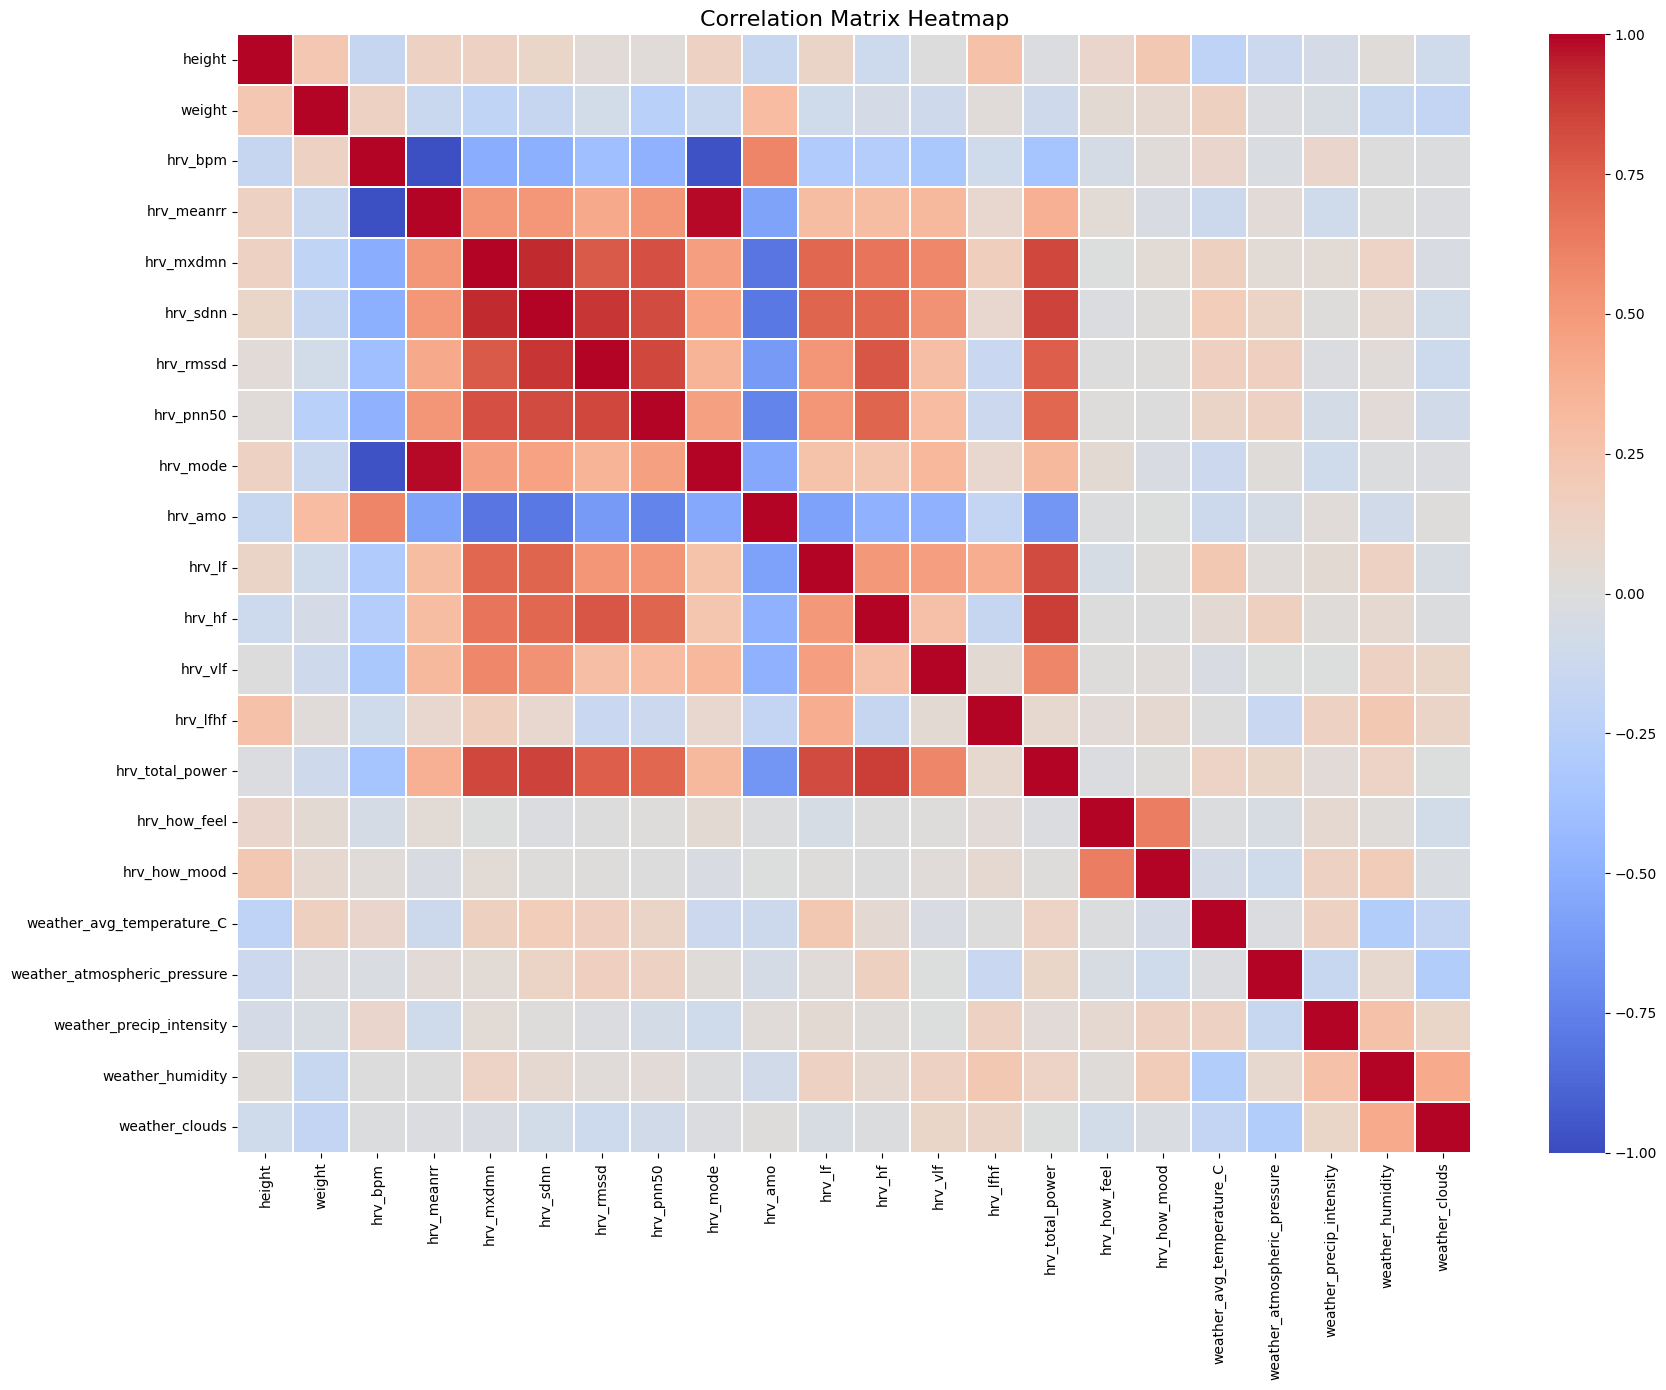


Strongest Feature Relationships:


,Feature 1,Feature 2,Correlation,Absolute Correlation
64,hrv_meanrr,hrv_mode,0.991033,0.991033
41,hrv_bpm,hrv_meanrr,-0.982904,0.982904
46,hrv_bpm,hrv_mode,-0.975027,0.975027
78,hrv_mxdmn,hrv_sdnn,0.924847,0.924847
95,hrv_sdnn,hrv_rmssd,0.898282,0.898282
178,hrv_hf,hrv_total_power,0.874686,0.874686
103,hrv_sdnn,hrv_total_power,0.854819,0.854819
111,hrv_rmssd,hrv_pnn50,0.837285,0.837285
87,hrv_mxdmn,hrv_total_power,0.836103,0.836103
96,hrv_sdnn,hrv_pnn50,0.821100,0.821100



Highly Correlated Feature Pairs (|r| >= 0.80):


,Feature 1,Feature 2,Correlation,Absolute Correlation
64,hrv_meanrr,hrv_mode,0.991033,0.991033
41,hrv_bpm,hrv_meanrr,-0.982904,0.982904
46,hrv_bpm,hrv_mode,-0.975027,0.975027
78,hrv_mxdmn,hrv_sdnn,0.924847,0.924847
95,hrv_sdnn,hrv_rmssd,0.898282,0.898282
178,hrv_hf,hrv_total_power,0.874686,0.874686
103,hrv_sdnn,hrv_total_power,0.854819,0.854819
111,hrv_rmssd,hrv_pnn50,0.837285,0.837285
87,hrv_mxdmn,hrv_total_power,0.836103,0.836103
96,hrv_sdnn,hrv_pnn50,0.821100,0.821100


In [16]:
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")

# Select numeric features
numeric_columns = master_df.select_dtypes(include=[np.number]).columns

# Calculate correlation matrix
correlation_matrix = master_df[numeric_columns].corr()


# ============================================================
# 1. Correlation Heatmap
# ============================================================

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,        # avoids clutter with lots of features
    linewidths=0.2
)

plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.tight_layout()
plt.show()


# ============================================================
# 2. Find Strongest Correlations
# ============================================================

# Convert correlation matrix into pairs of features
correlation_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

correlation_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

# Add absolute correlation for sorting
correlation_pairs["Absolute Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

# Sort strongest relationships first
correlation_pairs = correlation_pairs.sort_values(
    "Absolute Correlation",
    ascending=False
)

print("\nStrongest Feature Relationships:")
display(correlation_pairs.head(30))


# ============================================================
# 3. Specifically flag highly correlated features
# ============================================================

high_correlations = correlation_pairs[
    correlation_pairs["Absolute Correlation"] >= 0.80
]

print("\nHighly Correlated Feature Pairs (|r| >= 0.80):")
display(high_correlations)

## Interpretation

Positive correlation values (close to 1) indicate a strong direct relationship, while negative values (close to -1) indicate an inverse relationship.

It should not surprise use to see from the heat map that height and weight are somewhat correlated. However, the biggest takeaway here is that a lot of the hrv statistics are as correlated as it can get: very close to 1 or -1. Let's remove those features and re-do a correlation map before proceeding. 

Dropping redundant HRV features:
- hrv_meanrr
- hrv_mode
- hrv_mxdmn
- hrv_pnn50
- hrv_total_power

New dataset dimensions: (185, 20)


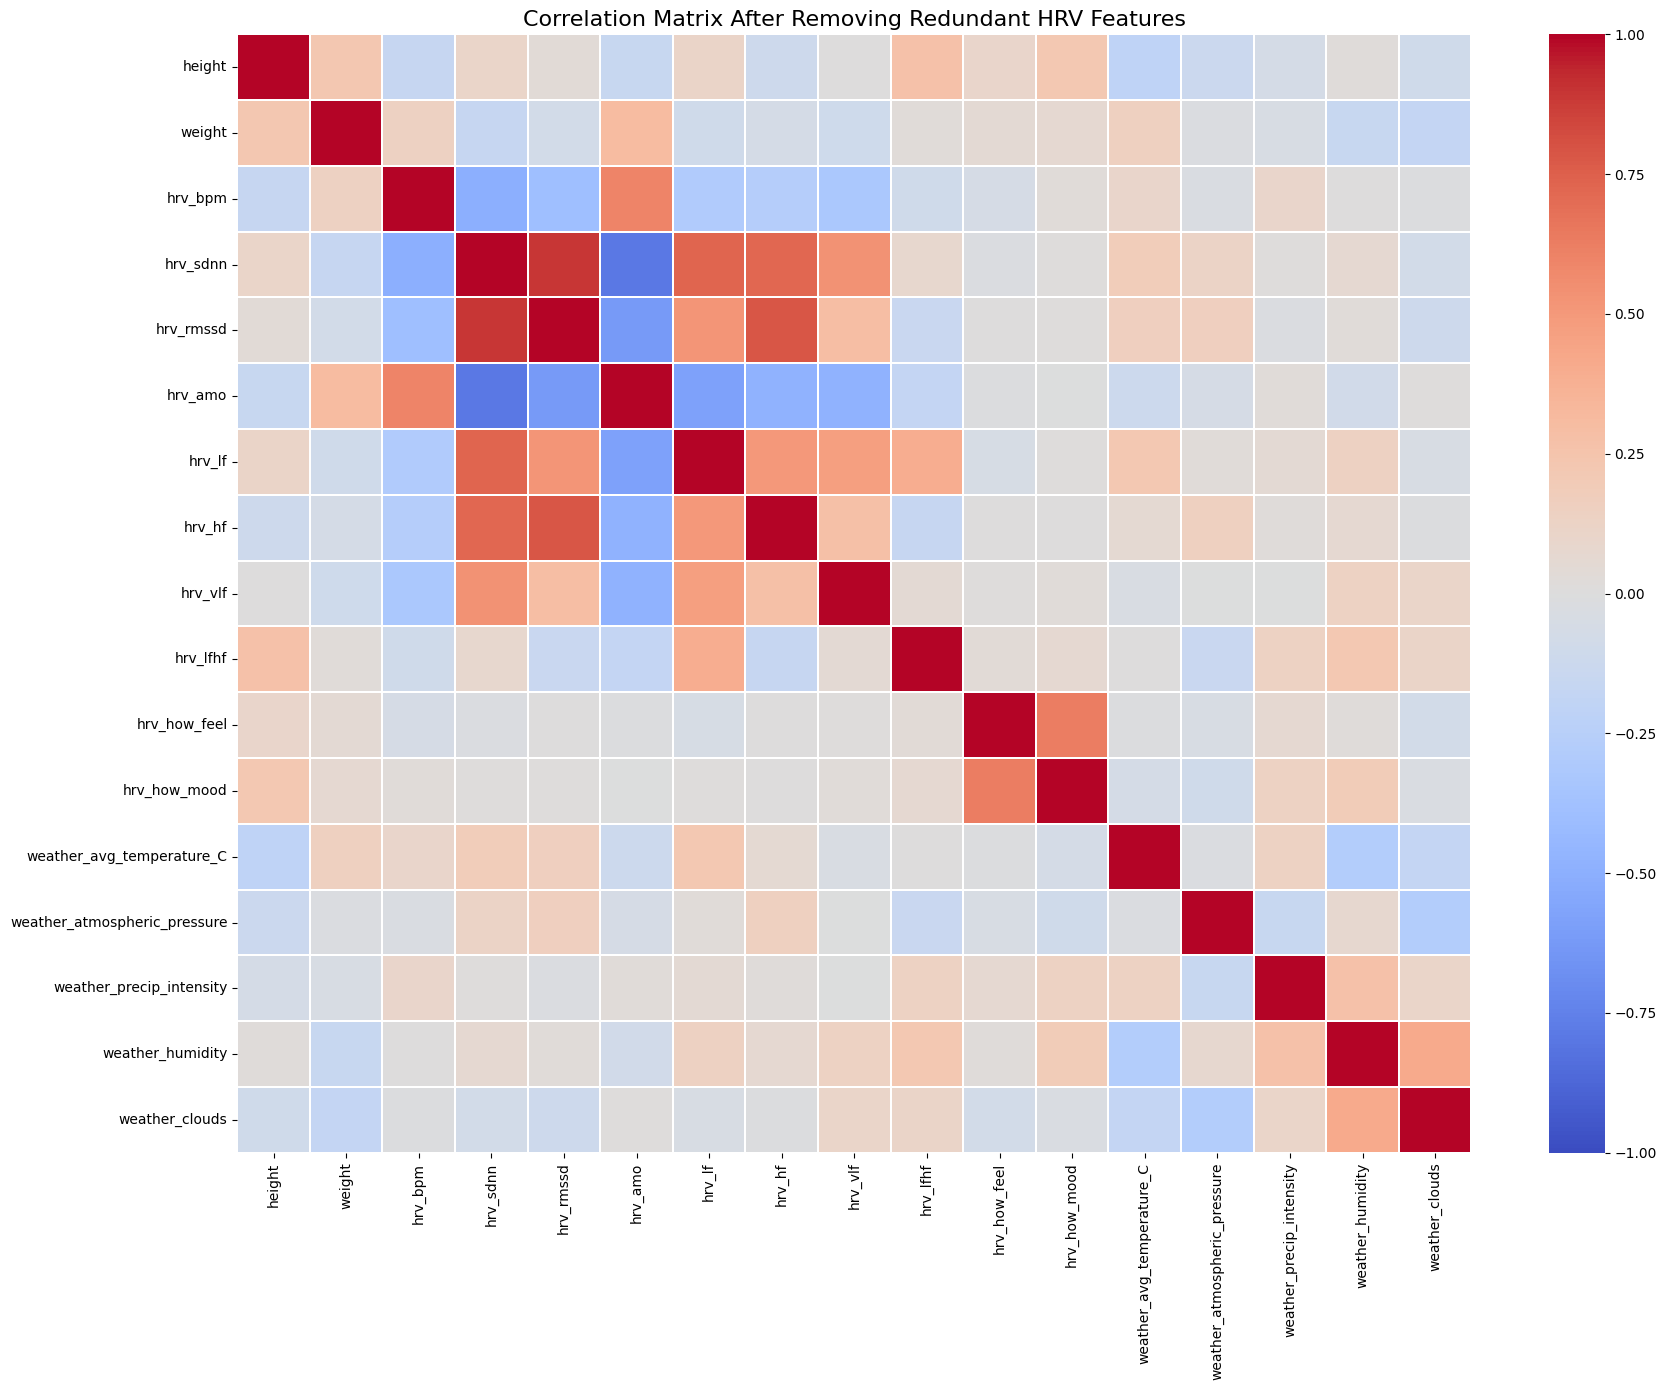


Strongest Remaining Correlations:


,Feature 1,Feature 2,Correlation,Absolute Correlation
45,hrv_sdnn,hrv_rmssd,0.898282,0.898282
46,hrv_sdnn,hrv_amo,-0.796016,0.796016
60,hrv_rmssd,hrv_hf,0.787523,0.787523
47,hrv_sdnn,hrv_lf,0.727671,0.727671
48,hrv_sdnn,hrv_hf,0.719000,0.719000
115,hrv_how_feel,hrv_how_mood,0.625858,0.625858
58,hrv_rmssd,hrv_amo,-0.621112,0.621112
33,hrv_bpm,hrv_amo,0.594188,0.594188
70,hrv_amo,hrv_lf,-0.585233,0.585233
49,hrv_sdnn,hrv_vlf,0.534194,0.534194


In [17]:
# ============================================================
# Remove highly redundant HRV features
# ============================================================

# Based on the correlation analysis above, keep representative
# HRV features and remove variables carrying very similar information.

hrv_features_to_drop = [
    "hrv_meanrr",       # highly correlated with hrv_bpm and hrv_mode
    "hrv_mode",         # highly correlated with hrv_bpm and hrv_meanrr

    "hrv_mxdmn",        # highly correlated with hrv_sdnn
    "hrv_pnn50",        # highly correlated with hrv_rmssd / hrv_sdnn

    "hrv_total_power"   # highly correlated with several HRV power/variability features
]

# Only drop columns that still exist
hrv_features_to_drop = [
    col for col in hrv_features_to_drop
    if col in master_df.columns
]

print("Dropping redundant HRV features:")
for col in hrv_features_to_drop:
    print(f"- {col}")

master_df = master_df.drop(columns=hrv_features_to_drop)

print(f"\nNew dataset dimensions: {master_df.shape}")


# ============================================================
# Recalculate correlations after feature removal
# ============================================================

numeric_columns = master_df.select_dtypes(include=[np.number]).columns
correlation_matrix = master_df[numeric_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.2
)

plt.title("Correlation Matrix After Removing Redundant HRV Features", fontsize=16)
plt.tight_layout()
plt.show()


# ============================================================
# Check strongest remaining correlations
# ============================================================

correlation_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Correlation"
]

correlation_pairs["Absolute Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

correlation_pairs = correlation_pairs.sort_values(
    "Absolute Correlation",
    ascending=False
)

print("\nStrongest Remaining Correlations:")
display(correlation_pairs.head(20))

## Interpretation

This is a definite improvement. There still is some correlation, but we do not need to remove all of it. Correlation is not that harmful: it really only affects our training time. More information is not always better, but at this point it doesn't really hurt. 

## Visualizing the Features More

* How can the variables be visualized effectively (histograms, scatterplots, box plots, etc.)?
* Do the visualizations reveal any interesting patterns or insights?
* Are there any subgroups or clusters that can be identified visually?


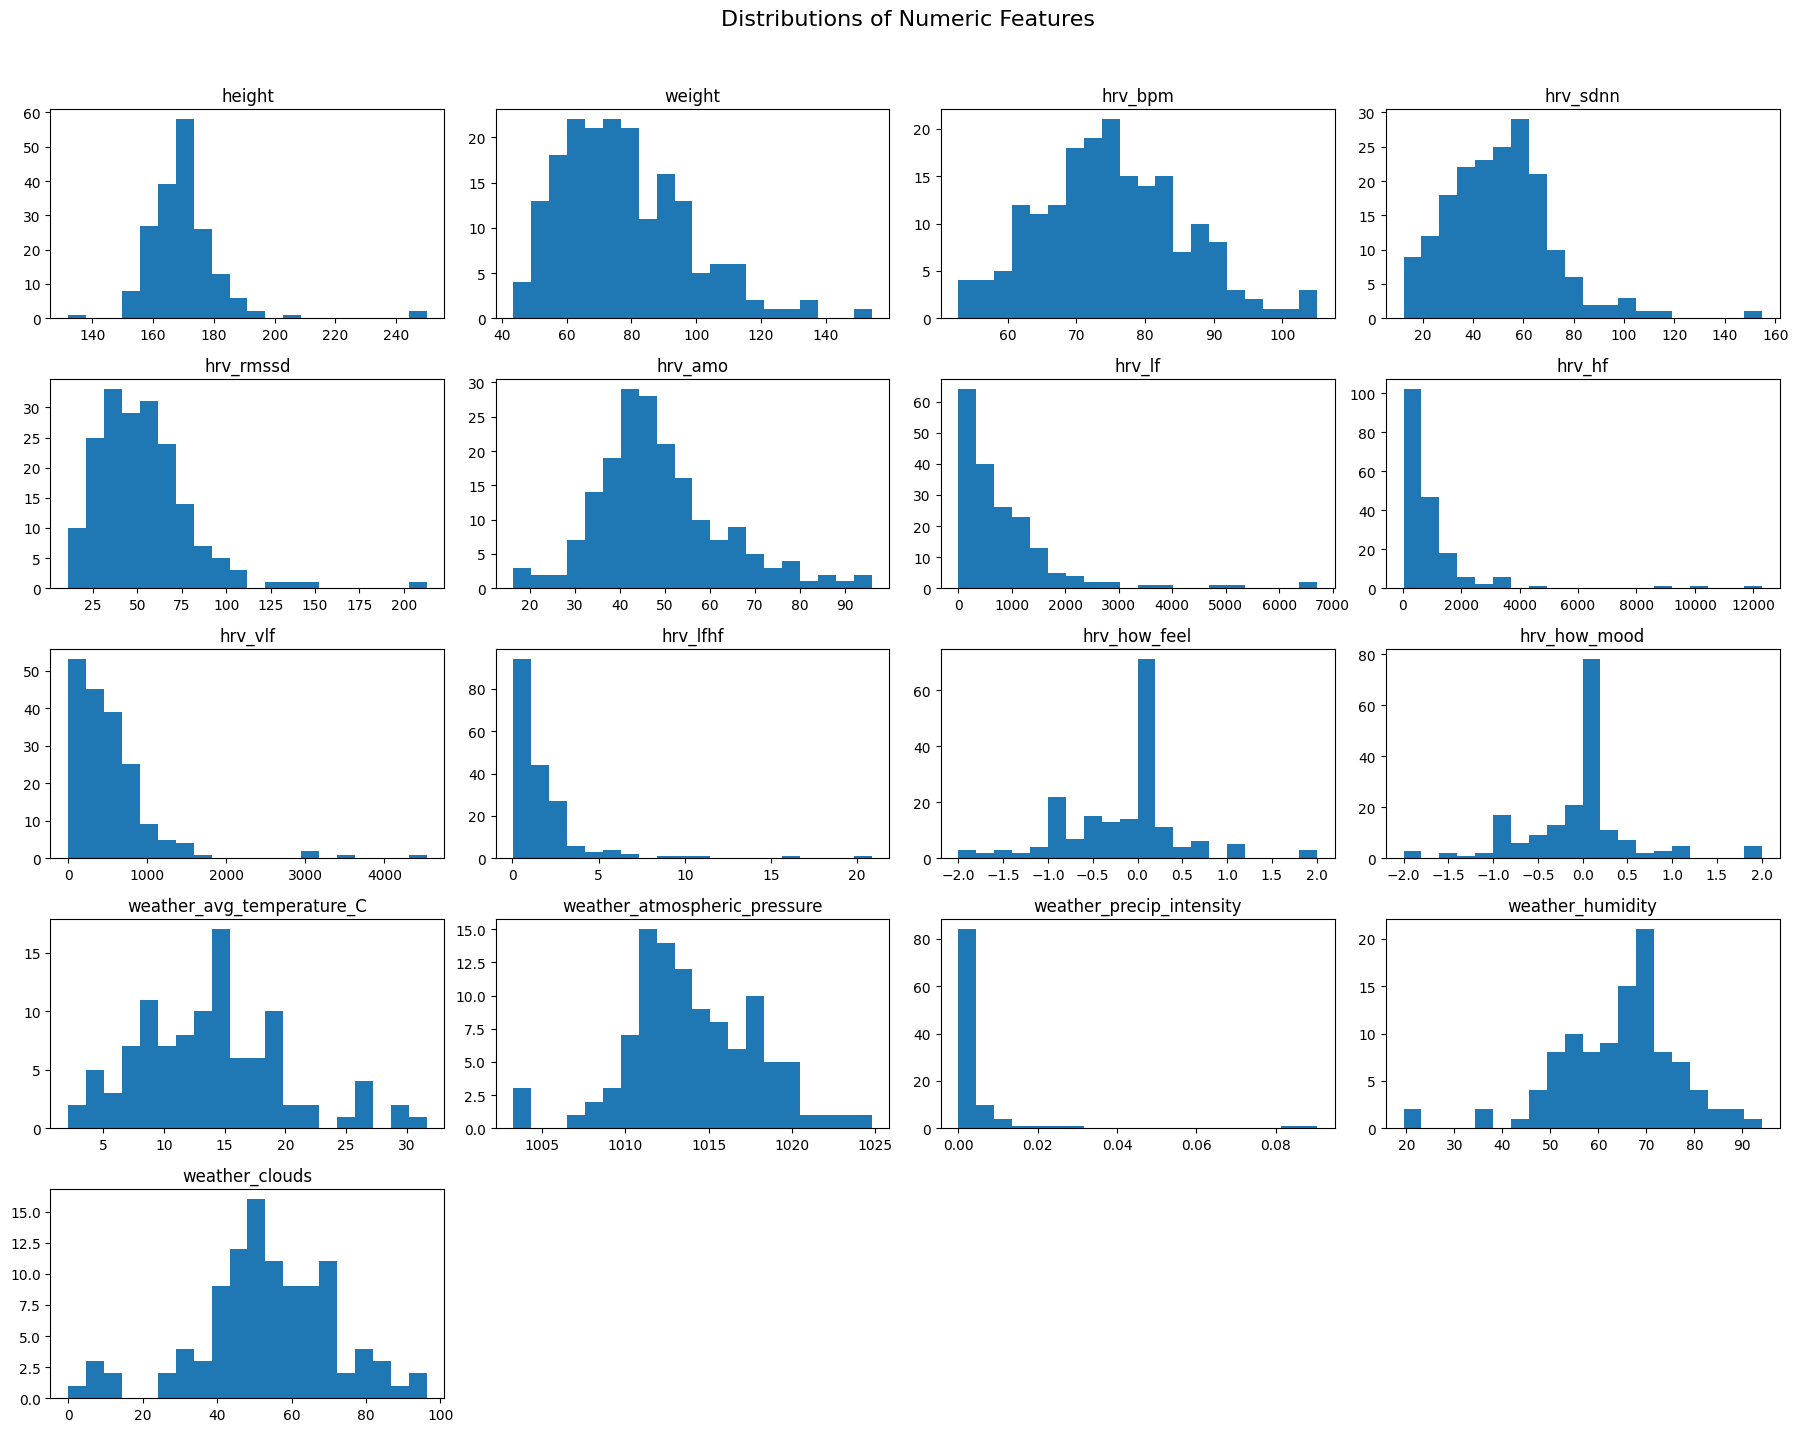

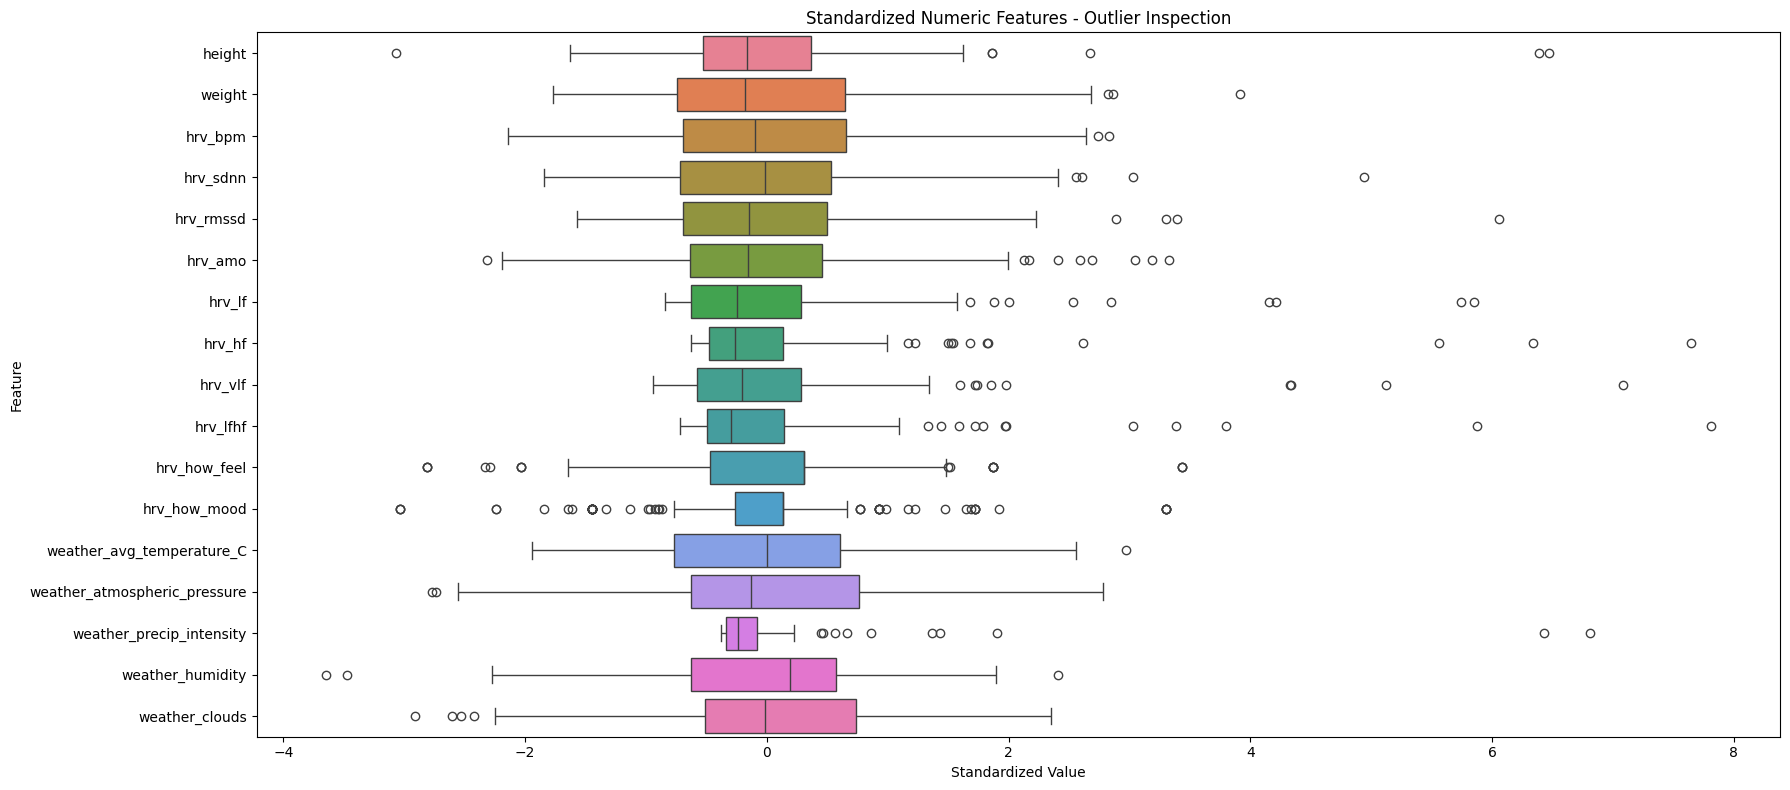

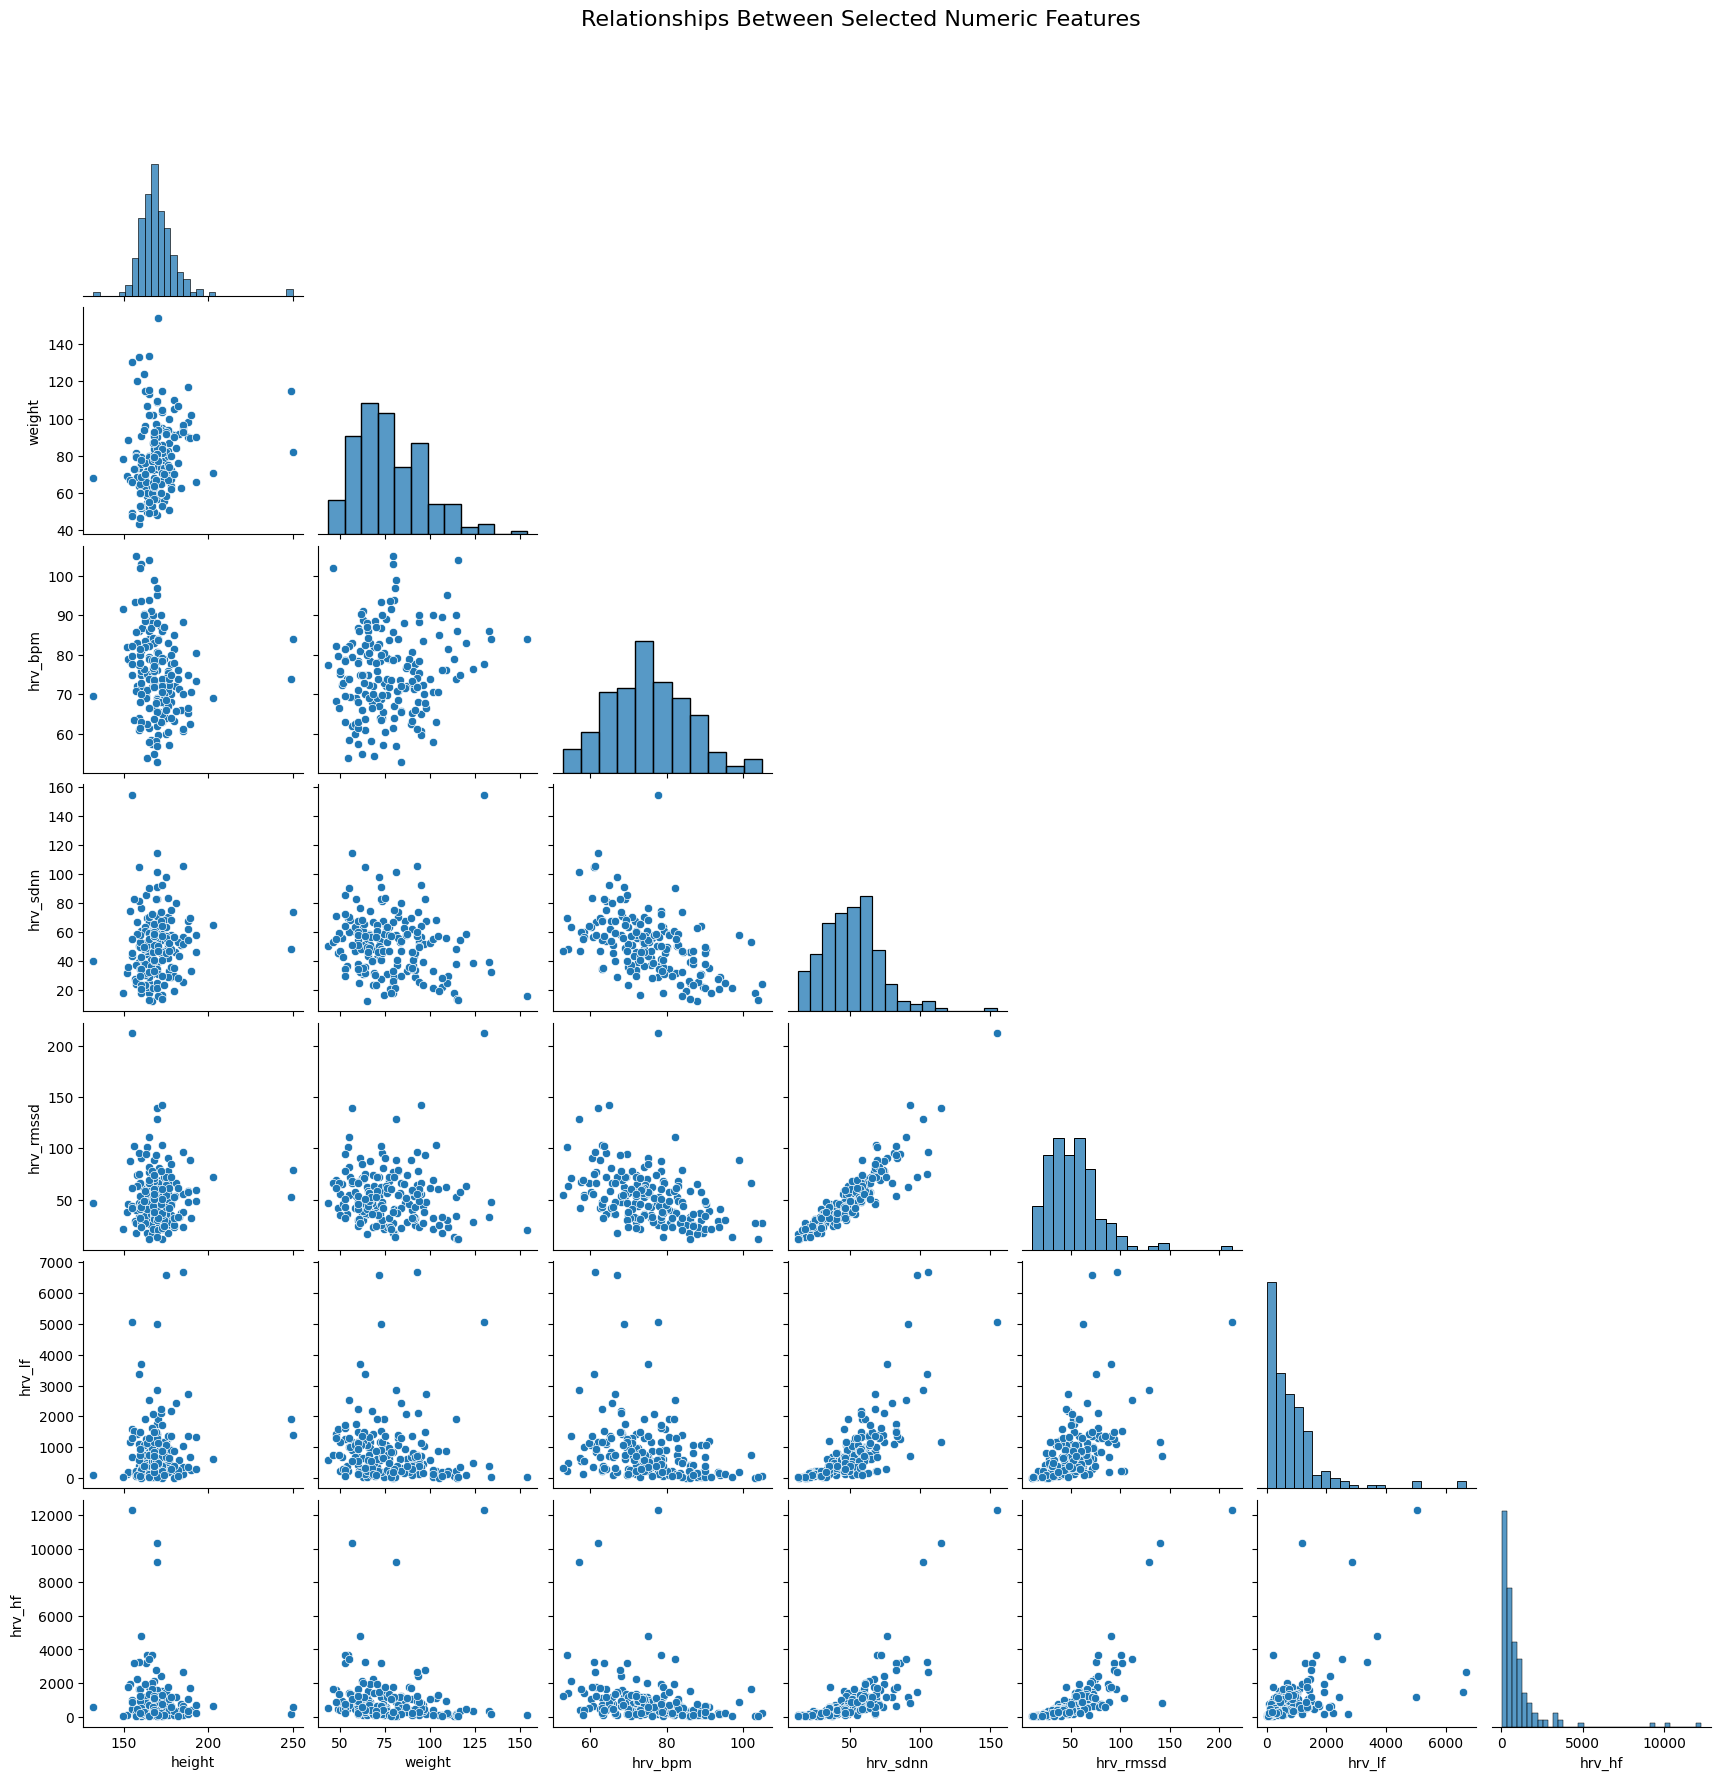

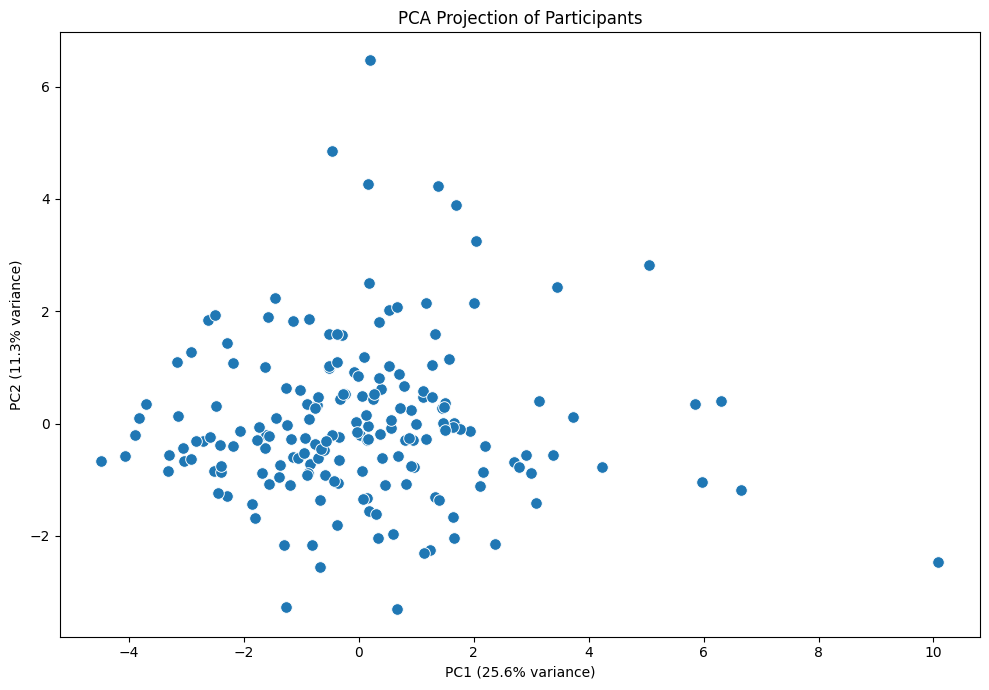

Variance explained by first two principal components: 36.92 %


In [18]:
# ============================================================
# Data Visualization
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Refresh numeric columns after our feature removal
numeric_columns = master_df.select_dtypes(include=[np.number]).columns


# ============================================================
# 1. Histograms - inspect distributions
# ============================================================

master_df[numeric_columns].hist(
    bins=20,
    figsize=(18, 14),
    grid=False
)

plt.suptitle("Distributions of Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# 2. Box plots - inspect potential outliers
# ============================================================
# Standardize first because our features have very different scales

standardized_data = pd.DataFrame(
    StandardScaler().fit_transform(master_df[numeric_columns]),
    columns=numeric_columns
)

plt.figure(figsize=(18, 8))

sns.boxplot(data=standardized_data, orient="h")

plt.title("Standardized Numeric Features - Outlier Inspection")
plt.xlabel("Standardized Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# ============================================================
# 3. Pair plot - inspect relationships between key variables
# ============================================================
# Do NOT pairplot every feature because it would become unreadable.
# Use a representative sample of meaningful features.

preferred_features = [
    "height",
    "weight",
    "hrv_bpm",
    "hrv_sdnn",
    "hrv_rmssd",
    "hrv_lf",
    "hrv_hf"
]

# Only use columns that actually remain in the dataset
pairplot_features = [
    col for col in preferred_features
    if col in master_df.columns
]

# If fewer than 4 of our preferred features exist,
# just use the first 6 numeric features
if len(pairplot_features) < 4:
    pairplot_features = list(numeric_columns[:6])

sns.pairplot(
    master_df[pairplot_features],
    diag_kind="hist",
    corner=True
)

plt.suptitle(
    "Relationships Between Selected Numeric Features",
    y=1.02,
    fontsize=16
)

plt.show()


# ============================================================
# 4. PCA - look for possible clusters/subgroups
# ============================================================
# PCA requires no missing values, so temporarily median-impute
# ONLY for this visualization.

pca_data = master_df[numeric_columns].copy()

pca_data = pca_data.fillna(
    pca_data.median()
)

# Standardize before PCA
scaled_data = StandardScaler().fit_transform(pca_data)

# Reduce all numeric variables down to 2 dimensions
pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame({
    "PC1": principal_components[:, 0],
    "PC2": principal_components[:, 1]
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    s=70
)

plt.title("PCA Projection of Participants")
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.tight_layout()
plt.show()

print(
    "Variance explained by first two principal components:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

## Interpretation

### Distributions

The histograms show that several variables are fairly well-behaved, while others are strongly skewed.

- Height, weight, BPM, and some weather variables have relatively compact distributions.
- Several HRV power features, especially `hrv_lf`, `hrv_hf`, `hrv_vlf`, and `hrv_lfhf`, are strongly right-skewed. Most participants have relatively low values, while a small number have very large values.
- Precipitation intensity is also heavily right-skewed, with most observations near zero.
- This suggests that some features may benefit from transformation or robust scaling before machine learning.

### Outliers

The standardized box plots reveal a number of potential outliers.

- The strongest outliers occur in several HRV features, particularly the frequency-domain measures.
- There are also a few unusual values in height, weight, humidity, atmospheric pressure, and precipitation.
- These observations should not automatically be removed, because they may represent real physiological or environmental differences. However, they should be investigated before modeling.

### Relationships Between Variables

The pair plot reveals several clear relationships.

- Height and weight show a positive relationship, which is expected.
- `hrv_bpm` appears negatively related to both `hrv_sdnn` and `hrv_rmssd`.
- `hrv_sdnn` and `hrv_rmssd` show a strong positive relationship.
- The HRV frequency-domain variables such as `hrv_lf` and `hrv_hf` also increase with several HRV variability measures, although their distributions contain substantial skew and outliers.

Overall, the HRV features still contain meaningful relationships even after removing the most redundant variables.

### Possible Subgroups

The PCA visualization reduces all numeric features into two dimensions so that we can look for broad clusters among participants.

The first two principal components explain approximately **36.9% of the total variance** in the numeric data. Most participants form one large overlapping group rather than several clearly separated clusters. There are, however, a small number of participants positioned far away from the main group.

At this stage, there is **no strong visual evidence of distinct subgroups**, but there are several unusual participants that may be worth investigating. The PCA plot also tells us that two dimensions capture only part of the variation in the dataset, so the lack of visible clusters does not necessarily mean that no meaningful subgroups exist.

## Let's Engineer One New Feature!

* Are there any new features that can be derived from the existing ones?
* Is there a need to transform or scale any variables?
* Are there any variables that can be combined or decomposed?



Feature Engineering
-------------------
New feature created: bmi

BMI Summary:


count    183.00
mean      27.16
std        7.17
min       13.14
25%       22.30
50%       26.24
75%       30.36
max       54.28
Name: bmi, dtype: float64

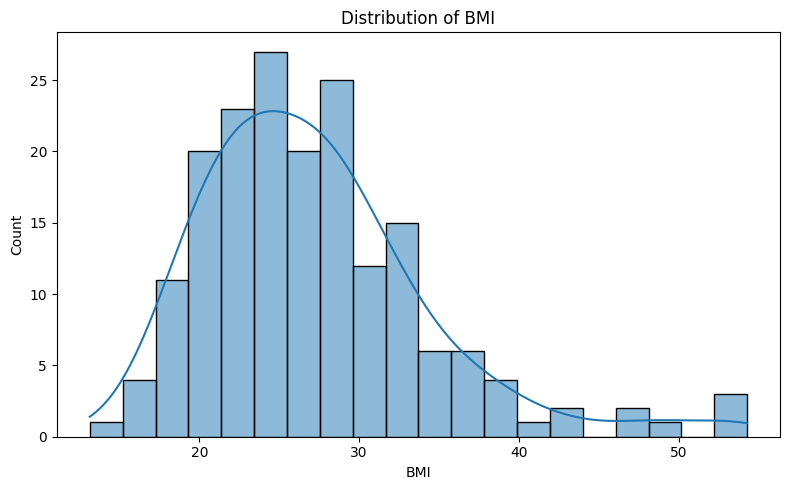

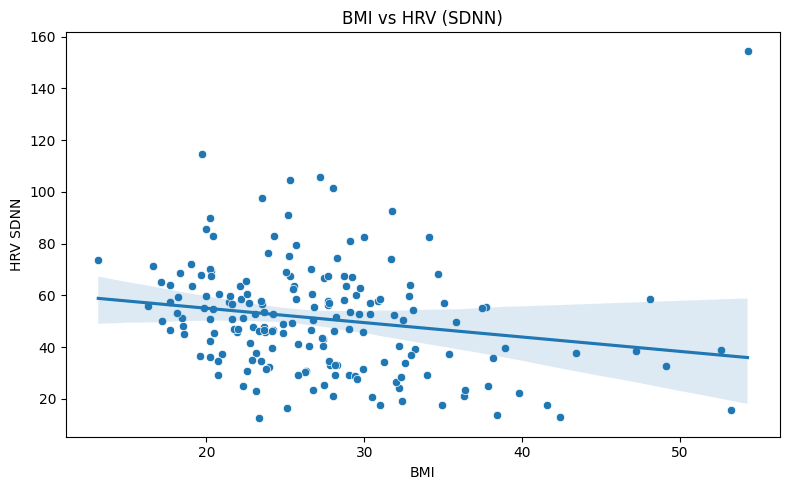


New dataset dimensions: (185, 21)


In [19]:
# ============================================================
# Feature Engineering: BMI
# ============================================================

print("\nFeature Engineering")
print("-------------------")

# BMI = weight (kg) / height (m)^2
# Height is currently stored in centimeters, so convert to meters first.

master_df["bmi"] = (
    master_df["weight"] /
    (master_df["height"] / 100) ** 2
)

print("New feature created: bmi")

# Quick summary
print("\nBMI Summary:")
display(master_df["bmi"].describe().round(2))


# ============================================================
# Visualize the new feature
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    master_df["bmi"],
    bins=20,
    kde=True
)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# ============================================================
# Compare BMI with a representative HRV measure
# ============================================================

if "hrv_sdnn" in master_df.columns:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=master_df,
        x="bmi",
        y="hrv_sdnn"
    )

    sns.regplot(
        data=master_df,
        x="bmi",
        y="hrv_sdnn",
        scatter=False
    )

    plt.title("BMI vs HRV (SDNN)")
    plt.xlabel("BMI")
    plt.ylabel("HRV SDNN")
    plt.tight_layout()
    plt.show()


print(f"\nNew dataset dimensions: {master_df.shape}")

## Interpretation

We created a new **BMI** feature by combining height and weight into a single measure of body size. The average BMI in the dataset is about **27.2**, with values ranging from about **13.1 to 54.3**, showing a fairly wide spread across participants.

The BMI distribution is somewhat right-skewed, with a few participants having much higher values than the majority. When comparing BMI with `hrv_sdnn`, there does not appear to be a very strong linear relationship, so BMI may provide information that is not already directly captured by this HRV measure.

We will keep BMI as a potential predictor and evaluate its usefulness later during modeling.

## Feature Transformations:

Given what we now know about the data, let's do some data transformation to adress the main skewness issues we observed before. We will do two things

1. Log-transform right-skewed data. 
2. Standardize numeric features on comparable scales. 

In [21]:
# ============================================================
# Data Transformation
# ============================================================

from sklearn.preprocessing import StandardScaler

# Make a copy so we preserve the original EDA dataset
transformed_df = master_df.copy()

print("Data Transformation")
print("-------------------")


# ============================================================
# 1. Reduce strong right-skew
# ============================================================
# Earlier EDA showed several HRV and weather variables with
# strong positive skew. We log-transform numeric features that:
#   1. have skewness > 1
#   2. contain no negative values
#
# log1p(x) = log(1 + x), so it also works when values are zero.

numeric_columns = transformed_df.select_dtypes(include=[np.number]).columns

skewness = transformed_df[numeric_columns].skew()

skewed_columns = [
    col for col in numeric_columns
    if skewness[col] > 1 and transformed_df[col].dropna().min() >= 0
]

print("Log-transforming strongly right-skewed features:")
for col in skewed_columns:
    print(f"- {col}: skewness = {skewness[col]:.2f}")
    transformed_df[col] = np.log1p(transformed_df[col])


# ============================================================
# 2. Standardize numeric variables
# ============================================================
# Standardization gives each variable approximately:
# mean = 0
# standard deviation = 1
#
# Fill missing numeric values with the median temporarily so
# StandardScaler can operate on the data.

numeric_columns = transformed_df.select_dtypes(include=[np.number]).columns

transformed_df[numeric_columns] = (
    transformed_df[numeric_columns]
    .fillna(transformed_df[numeric_columns].median())
)

scaler = StandardScaler()

transformed_df[numeric_columns] = scaler.fit_transform(
    transformed_df[numeric_columns]
)


# ============================================================
# 3. Inspect transformed dataset
# ============================================================

print(f"\nNumber of log-transformed features: {len(skewed_columns)}")
print(f"Number of standardized numeric features: {len(numeric_columns)}")

print("\nTransformed numeric feature summary:")
display(
    transformed_df[numeric_columns]
    .describe()
    .loc[["mean", "std", "min", "max"]]
    .round(3)
)

Data Transformation
-------------------
Log-transforming strongly right-skewed features:
- height: skewness = 2.91
- hrv_rmssd: skewness = 1.82
- hrv_lf: skewness = 3.23
- hrv_hf: skewness = 5.00
- hrv_vlf: skewness = 3.67
- hrv_lfhf: skewness = 4.52
- weather_precip_intensity: skewness = 5.79
- bmi: skewness = 1.28

Number of log-transformed features: 8
Number of standardized numeric features: 18

Transformed numeric feature summary:


,height,weight,hrv_bpm,hrv_sdnn,hrv_rmssd,hrv_amo,hrv_lf,hrv_hf,hrv_vlf,hrv_lfhf,hrv_how_feel,hrv_how_mood,weather_avg_temperature_C,weather_atmospheric_pressure,weather_precip_intensity,weather_humidity,weather_clouds,bmi
mean,0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003
min,-3.719,-1.766,-2.141,-1.846,-2.868,-2.314,-3.514,-2.571,-4.700,-1.490,-2.812,-3.034,-2.589,-3.602,-0.367,-4.935,-3.875,-2.798
max,5.791,3.913,2.834,4.944,3.110,3.331,2.155,2.791,2.374,4.201,3.435,3.304,3.966,3.766,9.053,3.080,3.142,2.986


## Interpretation

We now see much more normalized and standardized data! Good! This means features on larger scales will not dominate features on smaller scales in our data. We have reduced the impact of outliers as well, and adressed skewed concerns. 

## Comprehensive Data Quality Assessment (DQA) Summary

This notebook performed a broad data quality assessment before preparing the dataset for future modeling. The process touched all eight major dimensions of a DQA, although some dimensions were addressed more directly than others.

### 1. Profiling

We began by inspecting the structure of each source dataset, including dimensions, feature names, data types, missingness, distributions, descriptive statistics, skewness, kurtosis, and correlations.

After building the master dataset, we profiled it again using summary statistics, histograms, box plots, pair plots, correlation heatmaps, and PCA. This helped us understand the ranges, distributions, outliers, relationships, and general structure of the data.

### 2. Completeness

Missingness was one of the biggest issues in this dataset.

At the individual-dataset level, we first removed features with at least **5% missing values**. We then investigated overlap in `user_code` across the eight datasets and found that requiring every participant to appear in every dataset would leave only **4 users**, which was far too restrictive.

Instead, we selected the datasets with the strongest participant coverage:
- Participants
- HRV
- Weather
- Surveys

Participants and HRV formed the core population of **185 users**, while Weather and Surveys were added when available.

After merging, we used a looser **50% missingness threshold** at the master-dataset level so that useful Weather and Survey information would not be removed simply because those sources covered fewer participants.

### 3. Accuracy

Accuracy was assessed primarily through plausibility checks rather than comparison against an external gold-standard source.

We inspected:
- numerical ranges,
- descriptive statistics,
- extreme values,
- distributions,
- and outliers.

For example, unusual HRV, weather, height, weight, and BMI values were identified visually. We did **not automatically remove outliers**, because extreme physiological values may still represent legitimate observations.

A deeper accuracy audit against external trusted sources was not performed in this notebook, so this remains a limitation of the current DQA.

### 4. Consistency

A major consistency issue was that the datasets contained different subsets of participants and different numbers of observations per participant.

We synchronized records using `user_code` and analyzed overlap before deciding which data sources should contribute to the master dataset.

Because HRV, Weather, and Surveys contained repeated observations per user, we did not merge them directly row-by-row. Instead, repeated measurements were aggregated to the participant level before merging. This prevented many-to-many joins from artificially multiplying rows.

We also kept naming and data structures consistent during the merge by adding prefixes such as `hrv_`, `weather_`, and `survey_`.

### 5. Integrity

We treated `user_code` as the key linking the source datasets and verified overlap based on unique participant IDs.

The final master dataset was intentionally structured around **one row per participant**, which helped preserve entity integrity and prevented duplicate users from appearing simply because one source contained repeated measurements.

We also removed:
- identifier columns that should not be used as predictors,
- measurement-count bookkeeping fields,
- constant features,
- and highly redundant HRV variables.

This reduced the risk of invalid or meaningless features entering later analysis.

### 6. Lineage and Provenance

The notebook preserves a clear record of where the data came from and what transformations were applied.

The original source datasets were loaded separately, cleaned individually, then selectively combined into a participant-level master dataset.

The major processing steps were documented in sequence:

1. Inspect source datasets.
2. Remove heavily incomplete source features.
3. Measure participant overlap.
4. Select Participants, HRV, Weather, and Surveys.
5. Aggregate repeated measurements to user level.
6. Merge into a master dataset.
7. Remove sparse, constant, identifier, and redundant features.
8. Engineer BMI from height and weight.
9. Log-transform highly right-skewed non-negative variables.
10. Standardize numeric variables.

We also preserved `master_df` and created a separate `transformed_df`, which means the original cleaned values remain available alongside the transformed modeling version.

### 7. Automated Testing

Some automated validation logic was incorporated directly into the notebook.

Examples include automatically:
- calculating missing-value percentages,
- identifying sparse columns,
- detecting constant columns,
- computing user overlap,
- flagging highly correlated feature pairs,
- identifying strongly skewed variables,
- and checking whether columns exist before dropping them.

These checks make the workflow more reproducible and reduce reliance on manually inspecting every feature.

However, this is not yet a full automated testing pipeline. A production-quality workflow could later include assertions for expected row counts, unique IDs, valid ranges, schema checks, and maximum allowable missingness.

### 8. Continuous Monitoring

Continuous monitoring is not directly applicable to this static classroom dataset because the data are not currently arriving as a live stream.

However, if this analysis were converted into a real production pipeline, the same quality metrics should be recalculated whenever new data arrive. Important quantities to monitor would include missingness, participant coverage, feature distributions, outlier rates, schema changes, and unexpected shifts in correlations or ranges.

## Overall Result

The original data were fragmented, sparse, and inconsistent across sources. Rather than forcing all eight datasets together and reducing the usable sample to only four participants, we made a series of deliberate quality decisions to preserve a much larger and more useful study population.

The resulting dataset contains **185 participant-level observations** built primarily from participant information, HRV measurements, weather information, and survey data. We then reduced unnecessary and redundant features, engineered BMI, addressed strong skewness, and standardized numeric variables.

Overall, the DQA transformed a messy collection of source files into a substantially cleaner, more consistent, and more model-ready dataset while preserving a clear record of the decisions made along the way.